In [88]:
max_p = 200

def get_colorscale(p):     
    if (p <= 1): 
        return 'Reds'
    elif (p < 2): 
        return 'Oranges'
    elif (p == 2): 
        return 'Greens'
    elif (p == max_p): 
        return 'Purples'
    return 'Blues'

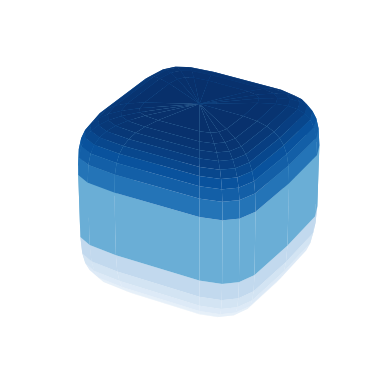

In [89]:
# superellipsoid 

import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(0, 2 * np.pi, 20)  # азимутальный угол
v = np.linspace(0, np.pi, 20)      # полярный угол
u, v = np.meshgrid(u, v)

# Параметризация 
p = 5

X = np.sign(np.cos(u)) * np.abs(np.cos(u)) ** (2/p) * \
    np.sign(np.sin(v)) * np.abs(np.sin(v)) ** (2/p)
Y = np.sign(np.sin(u)) * np.abs(np.sin(u)) ** (2/p) * \
    np.sign(np.sin(v)) * np.abs(np.sin(v)) ** (2/p)
Z = np.sign(np.cos(v)) * np.abs(np.cos(v)) ** (2/p)

    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((8, 8, 7))
colormap = get_colorscale(p);
ax.plot_surface(X, Y, Z, cmap=colormap)
ax.axis('off')
plt.savefig("superellipsoid.svg", format='svg', bbox_inches='tight')

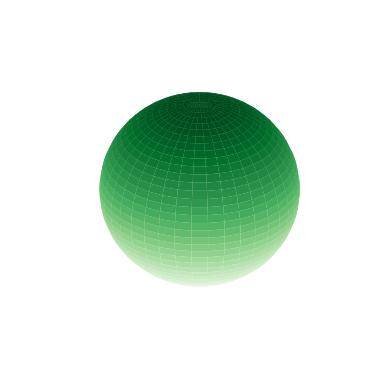

In [90]:
# ball

u = np.linspace(0, 2 * np.pi, 40)  # азимутальный угол
v = np.linspace(0, np.pi, 40)      # полярный угол
u, v = np.meshgrid(u, v)

dx = np.sin(v) * np.cos(u)
dy = np.sin(v) * np.sin(u)
dz = np.cos(v)

X = dx
Y = dy
Z = dz

p=2;
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((8, 8, 7))
colormap = get_colorscale(p);
ax.plot_surface(X, Y, Z, cmap=colormap)
ax.axis('off')
plt.savefig("ball.svg", format='svg', bbox_inches='tight')

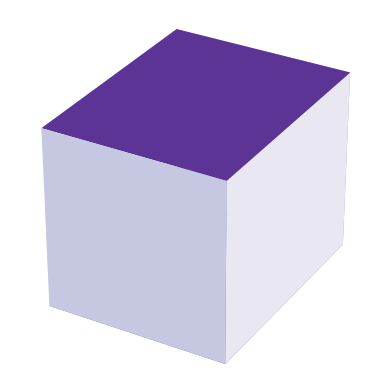

In [91]:
# cube

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 6 граней-квадратов: фиксируем одну координату на +-1, обходим углы по кругу
faces = []
for axis in range(3):
    u_ax, v_ax = [i for i in range(3) if i != axis]
    for sign in (-1, 1):
        quad = []
        for a, b in [(-1, -1), (1, -1), (1, 1), (-1, 1)]:
            pnt = np.zeros(3)
            pnt[u_ax], pnt[v_ax], pnt[axis] = a, b, sign
            quad.append(pnt)
        faces.append(np.array(quad))

p = max_p;
colormap = get_colorscale(p);
cmap = mpl.colormaps[colormap]
face_colors = [cmap(i / len(faces)) for i in range(len(faces))]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((8, 10, 8))
ax.add_collection3d(Poly3DCollection(faces, facecolors=face_colors))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.axis('off')
plt.savefig("cube.svg", format='svg', bbox_inches='tight')

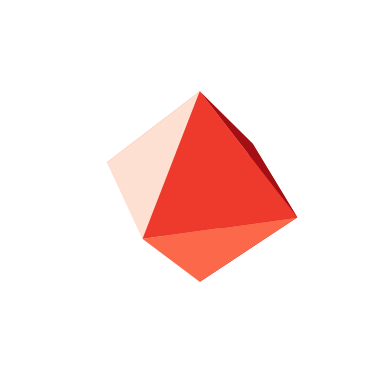

In [92]:
# octahedron

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 8 граней-треугольников: по одной вершине от каждой пары противоположных
faces = []
for x in (-1, 1):
    for y in (-1, 1):
        for z in (-1, 1):
            faces.append(np.array([(x, 0, 0), (0, y, 0), (0, 0, z)]))

p = 1;
colormap = get_colorscale(p);
cmap = mpl.colormaps[colormap]
face_colors = [cmap(i / len(faces)) for i in range(len(faces))]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1, 1, 1))
ax.add_collection3d(Poly3DCollection(faces, facecolors=face_colors))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.axis('off')
plt.savefig("octahedron.svg", format='svg', bbox_inches='tight')